# <b> In this Assignment i will be working on camparing Logistic Regression with SVM model and make a comparization bar chat that shows which one is the best model for the dataset which I used here.

# <b> Step-1 Reading the csv file in the jupyter notebook using pandas.

In [4]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Sai Lalit\Downloads\insurance_claim_approval_dataset_fixed.csv")
df.head()

,Claim_ID,Customer_Age,Policy_Type,Years_With_Company,Claim_Amount,Number_of_Previous_Claims,Policy_Premium,Documentation_Complete,Claim_Type,Customer_Rating,Fraud_Flag,Agent_Review_Score,Claim_Approved
0,1,31.0,Travel,2,10917.0,6,5036,Yes,Theft,3.0,No,1,No
1,2,59.0,Life,22,NaN,1,6393,Yes,Accident,1.0,No,6,Yes
2,3,59.0,Life,22,47693.0,7,6630,Yes,Accident,4.0,No,3,No
3,4,38.0,Auto,22,44801.0,4,984,Yes,Accident,2.0,No,1,No
4,5,23.0,Health,8,19056.0,7,6355,No,Theft,1.0,No,1,No


<b> First I have written the code to read the csv file which i downloaded.

In [5]:
df.columns # finding what are the columns in the dataset

Index(['Claim_ID', 'Customer_Age', 'Policy_Type', 'Years_With_Company',
       'Claim_Amount', 'Number_of_Previous_Claims', 'Policy_Premium',
       'Documentation_Complete', 'Claim_Type', 'Customer_Rating', 'Fraud_Flag',
       'Agent_Review_Score', 'Claim_Approved'],
      dtype='object')

<b> Showing the general information of the data

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Claim_ID                   366 non-null    int64  
 1   Customer_Age               360 non-null    float64
 2   Policy_Type                360 non-null    object 
 3   Years_With_Company         366 non-null    int64  
 4   Claim_Amount               360 non-null    float64
 5   Number_of_Previous_Claims  366 non-null    int64  
 6   Policy_Premium             366 non-null    int64  
 7   Documentation_Complete     359 non-null    object 
 8   Claim_Type                 360 non-null    object 
 9   Customer_Rating            359 non-null    float64
 10  Fraud_Flag                 366 non-null    object 
 11  Agent_Review_Score         366 non-null    int64  
 12  Claim_Approved             366 non-null    object 
dtypes: float64(3), int64(5), object(5)
memory usage: 3

<b> Now i want to see the datatypes in the csv file.

In [7]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Sai Lalit\Downloads\insurance_claim_approval_dataset_fixed.csv")
df.dtypes # defining the datatypes in the dataset.

Claim_ID                       int64
Customer_Age                 float64
Policy_Type                   object
Years_With_Company             int64
Claim_Amount                 float64
Number_of_Previous_Claims      int64
Policy_Premium                 int64
Documentation_Complete        object
Claim_Type                    object
Customer_Rating              float64
Fraud_Flag                    object
Agent_Review_Score             int64
Claim_Approved                object
dtype: object

# <b> Step-2 Finding out the business problems, ML problem and prediction goals.

In [8]:
# business problem

business_problem = " An insurence company wants to predict which customer will get the insurence claim approvals"

# machine learning problem

Ml_problem = " This is a classification problem because we wants to predict whether the customer will get approvals are not"

# Prediction goal

prediction_goal = " we are predicting whether a customer will get insurence claim approvals: Yes or No."

print("Businesss problems:")
print(business_problem)

print("ML problems:")
print(Ml_problem)

print("prediction goal:")
print(prediction_goal)


Businesss problems:
 An insurence company wants to predict which customer will get the insurence claim approvals
ML problems:
 This is a classification problem because we wants to predict whether the customer will get approvals are not
prediction goal:
 we are predicting whether a customer will get insurence claim approvals: Yes or No.


### In this dataset the features are customer_age, ploicy_type, years with company,claim amount,number of previous claims,policy premium,documentation complete, claim type, customer rating, fraud flag, and agent review score columns.
### The target is the claim approved column.

# <b> step-3 Defining Features and Target columns and shapes of both columns

In [9]:
# Feature columns

feature_columns = [
    "Customer_Age",
    "Policy_Type",
    "Years_With_Company",
    "Claim_Amount",
    "Number_of_Previous_Claims",
    "Policy_Premium",
    "Documentation_Complete",
    "Claim_Type",
    "Customer_Rating",
    "Fraud_Flag",
    "Agent_Review_Score"]

target_column = ["Claim_Approved"]

x = df[feature_columns]

y = df[target_column]

print("shape of x:" , x.shape)

print("shape of y:", y.shape)

shape of x: (366, 11)
shape of y: (366, 1)


## <b> I want to know the missing and duplicate values in the dataset

In [10]:
# Here, I want to know the missing and duplicate values in the dataset

print("Missing values in each columns:")
print(df.isnull().sum())

print("\n")

print("Number of duplicate rows:")
print(df.duplicated().sum())


Missing values in each columns:
Claim_ID                     0
Customer_Age                 6
Policy_Type                  6
Years_With_Company           0
Claim_Amount                 6
Number_of_Previous_Claims    0
Policy_Premium               0
Documentation_Complete       7
Claim_Type                   6
Customer_Rating              7
Fraud_Flag                   0
Agent_Review_Score           0
Claim_Approved               0
dtype: int64


Number of duplicate rows:
6


In [11]:
# To start the basic cleaning process, I will create a copy of that dataset so that the raw data will not change

df_clean = df.copy()
print("original dataset shape:")

print(df_clean.shape)

original dataset shape:
(366, 13)


## Cleaning the duplicate values in the dataset

In [12]:
# Cleaning the duplicate values

df_clean = df_clean.drop_duplicates() # removing the duplicate rows in the copied dataset

print(" Dataset after removing the duplicate rows:")

print(df_clean.shape)

print("Number of duplicate rows after cleaning:")
print(df_clean.duplicated().sum())

 Dataset after removing the duplicate rows:
(360, 13)
Number of duplicate rows after cleaning:
0


## Cleaning the missing values in the dataset

In [13]:
# For Cleaning the Missing values, first we will split the numeric and categoric columns 

numeric_columns = [
     "Customer_Age",
    "Years_With_Company",
    "Claim_Amount",
    "Number_of_Previous_Claims",
    "Policy_Premium",
    "Customer_Rating",
    "Agent_Review_Score"] # The columns are numeric

categoric_columns = [
    "Policy_Type",
    "Documentation_Complete",
    "Claim_Type",
    "Fraud_Flag"] # The columns are string

for column in numeric_columns: 
    median_value = df_clean[column].median() #  # Calculating the median value of the each column
    df_clean[column] = df_clean[column].fillna(median_value) # Filling the median values in the columns

for column in categoric_columns: 
    most_frequent_value = df_clean[column].mode()[0] # Finding the most frequent value in the columns
    df_clean[column] = df_clean[column].fillna(most_frequent_value) # Filling the frequent values in the columns.  

print("Missing values after cleaning:") 

print(df_clean.isnull().sum())

print("\nCleaned dataset preview:")

display(df_clean.head())

Missing values after cleaning:
Claim_ID                     0
Customer_Age                 0
Policy_Type                  0
Years_With_Company           0
Claim_Amount                 0
Number_of_Previous_Claims    0
Policy_Premium               0
Documentation_Complete       0
Claim_Type                   0
Customer_Rating              0
Fraud_Flag                   0
Agent_Review_Score           0
Claim_Approved               0
dtype: int64

Cleaned dataset preview:


,Claim_ID,Customer_Age,Policy_Type,Years_With_Company,Claim_Amount,Number_of_Previous_Claims,Policy_Premium,Documentation_Complete,Claim_Type,Customer_Rating,Fraud_Flag,Agent_Review_Score,Claim_Approved
0,1,31.0,Travel,2,10917.0,6,5036,Yes,Theft,3.0,No,1,No
1,2,59.0,Life,22,24215.0,1,6393,Yes,Accident,1.0,No,6,Yes
2,3,59.0,Life,22,47693.0,7,6630,Yes,Accident,4.0,No,3,No
3,4,38.0,Auto,22,44801.0,4,984,Yes,Accident,2.0,No,1,No
4,5,23.0,Health,8,19056.0,7,6355,No,Theft,1.0,No,1,No


## <b> Step-4 Defining the feature and target variables.

In [14]:
# In this step, we are finding the X and Y variables. X means the input/feature variables and Y means target variables.

feature_variables = [ "Customer_Age",
    "Policy_Type",
    "Years_With_Company",
    "Claim_Amount",
    "Number_of_Previous_Claims",
    "Policy_Premium",
    "Documentation_Complete",
    "Claim_Type",
    "Customer_Rating",
    "Fraud_Flag",
    "Agent_Review_Score"]

target_variables = "Claim_Approved"

x = df_clean[feature_variables]
y = df_clean[target_variables]

print("shape of x:")
print(x.shape)

print("\n shape of y:")
print(y.shape)

# printing the total count of target variables

print("\nBefore converting the target variables:")
print(y.value_counts())

shape of x:
(360, 11)

 shape of y:
(360,)

Before converting the target variables:
Claim_Approved
No     202
Yes    158
Name: count, dtype: int64


### <b> Before starting the ML algorithem we need to convert the target variable from string to numeric values. 

In [15]:
# In machine learning algotherm we neet to convert all string data into numeric to read the data

y = y.map({"No": 0, "Yes": 1})
print("Target variables after convertion:")
print(y.value_counts())

Target variables after convertion:
Claim_Approved
0    202
1    158
Name: count, dtype: int64


# <b> Step-5 Train and Test splitting the dataset.

Here we need to split the dataset into training data and testing data after defining the x and y.

In this code 

x_train = input features used for training.

x_test = input features used for testing

y_train = target values used for training

y_test = target values used for testing


The training set is used to teach the model.

The testing set is used to evaluating the model.

We use these sets to findout the actual results in the dataset.

In [16]:
# Now we need to split the data into training and testing sets of data.

from sklearn.model_selection import train_test_split  # Import train_test_split to divide the data into training and testing sets

x_train, x_test, y_train, y_test = train_test_split(  # Split features and target into train and test sets
    x,  # Input features
    y,  # Target variable
    test_size=0.20,  # Use 20% of the data for testing
    random_state=42,  # Make the split reproducible
    stratify=y  # Keep the same proportion of 0 and 1 in train and test sets
)

print("Shape of x_train:")  # Print a title for X_train shape

print(x_train.shape)  # Show the number of rows and columns in X_train

print("\nShape of x_test:")  # Print a title for X_test shape

print(x_test.shape)  # Show the number of rows and columns in X_test

print("\nShape of y_train:")  # Print a title for y_train shape

print(y_train.shape)  # Show the number of target values in y_train

print("\nShape of y_test:")  # Print a title for y_test shape

print(y_test.shape)

Shape of x_train:
(288, 11)

Shape of x_test:
(72, 11)

Shape of y_train:
(288,)

Shape of y_test:
(72,)


In [15]:
print("Target distribution in y_train:")  # Print a title for target distribution in the training set

print(y_train.value_counts())  # Count the number of 0 and 1 values in y_train

print("\nTarget distribution in y_test:")  # Print a title for target distribution in the testing set

print(y_test.value_counts())

Target distribution in y_train:
Claim_Approved
0    162
1    126
Name: count, dtype: int64

Target distribution in y_test:
Claim_Approved
0    40
1    32
Name: count, dtype: int64


# <b>  Step - 6 Preprocessing the Dataset before applying the ML aglorithem 

We use the processing step to avoid the data leakage.

In this code we are using <b>  standardScaler for scaling the numerical columns.

and <b> One HotEncoder is used for converting the categoric columns into numbers.

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_columns = [
     "Customer_Age",
    "Years_With_Company",
    "Claim_Amount",
    "Number_of_Previous_Claims",
    "Policy_Premium",
    "Customer_Rating",
    "Agent_Review_Score"] # The columns are numeric

categoric_columns = [
    "Policy_Type",
    "Documentation_Complete",
    "Claim_Type",
    "Fraud_Flag"] # The columns are string

preprocessor = ColumnTransformer(  # Create a preprocessing object for numerical and categorical columns
    transformers=[  # Define the preprocessing steps
        ("num", StandardScaler(), numeric_columns),  # Scaling numerical columns
        ("cat", OneHotEncoder(handle_unknown="ignore"), categoric_columns)  # Encoded categorical columns
    ] 
) 

In [22]:
x_train_preprocessed = preprocessor.fit_transform(x_train)  # Fit the preprocessor on the training data and transform X_train

print("X_train preprocessing completed!")

print("\n")

x_test_preprocessed = preprocessor.transform(x_test)  # Apply the same preprocessing steps to X_test

print("X_test preprocessing completed!")

print("\n")

print("Summary of preprocessing shapes:")  # Print a title for the shape summary

print("X_train before preprocessing:", x_train.shape)  # Print X_train shape before preprocessing

print("X_train after preprocessing:", x_train_preprocessed.shape)  # Print X_train shape after preprocessing

print("X_test before preprocessing:", x_test.shape)  # Print X_test shape before preprocessing

print("X_test after preprocessing:", x_test_preprocessed.shape)  # Print X_test shape after preprocessing


X_train preprocessing completed!


X_test preprocessing completed!


Summary of preprocessing shapes:
X_train before preprocessing: (288, 11)
X_train after preprocessing: (288, 21)
X_test before preprocessing: (72, 11)
X_test after preprocessing: (72, 21)


## <b>  Step-7 Building a baseline model using Logistic Regression.

In this step, we use Logistic Regression because:

It is simple and easy to understand.

It is commonly used for binary classification.

Our target variable has two classes: 0 and 1.

It can predict whether a customer will get claim approval or not.

In [23]:
# Now we are using the logistic regression model to predict the output data using our x_train_preprocessed and y_train.

from sklearn.linear_model import LogisticRegression # Import Logistic Regression model from scikit-learn
logistic_model = LogisticRegression(max_iter=1000, random_state=42)  # Create a Logistic Regression model

logistic_model.fit(x_train_preprocessed, y_train)  # Train the Logistic Regression model using the preprocessed training data

print("Logistic Regression model trained successfully!")

y_pred_logistic = logistic_model.predict(x_test_preprocessed)  # Use the trained model to predict the target values for X_test

print("\nPredictions completed successfully!")

print("\nFirst 10 predictions:")  # Print a title for the first predictions

print(y_pred_logistic[:10])  # Display the first 10 predicted values


Logistic Regression model trained successfully!

Predictions completed successfully!

First 10 predictions:
[0 1 0 1 1 0 0 0 0 1]


In [24]:
# now we are just comparing the predicted output with our actual y_train data

comparison_df = pd.DataFrame({  # Create a DataFrame to compare actual and predicted values
    "Actual": y_test.values,  # Add the real target values from y_test
    "Predicted": y_pred_logistic  # Add the predicted values from the Logistic Regression model
})  # End of DataFrame creation

display(comparison_df.head(10))

,Actual,Predicted
0,0,0
1,1,1
2,0,0
3,0,1
4,1,1
5,1,0
6,1,0
7,0,0
8,0,0
9,1,1


## <b> Step 8: Evaluating the Logistic Regression Model

The Model evaluation will help us to understand how the model works in the test data. 

In here we are using 

1) Confusion Matrix
2) Accuracy
3) Precision
4) Recall
5) F1-score

In [25]:
from sklearn.metrics import confusion_matrix  # Import confusion_matrix to compare actual and predicted classes

from sklearn.metrics import ConfusionMatrixDisplay  # Import ConfusionMatrixDisplay to visualize the confusion matrix

from sklearn.metrics import accuracy_score  # Import accuracy_score to calculate accuracy

from sklearn.metrics import precision_score  # Import precision_score to calculate precision

from sklearn.metrics import recall_score  # Import recall_score to calculate recall

from sklearn.metrics import f1_score  # Import f1_score to calculate F1-score

from sklearn.metrics import classification_report  # Import classification_report to show all evaluation metrics together

import matplotlib.pyplot as plt  # Import matplotlib for creating plots

In [26]:
cm_method = confusion_matrix(y_test, y_pred_logistic)  # Create the confusion matrix using actual and predicted values

print("Confusion Matrix:")

print(cm_method)  # Display the confusion matrix as numbers

Confusion Matrix:
[[31  9]
 [ 6 26]]


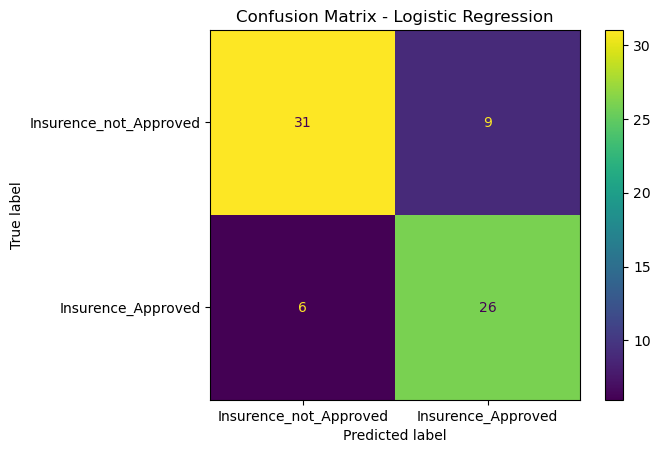

In [27]:
display_cm = ConfusionMatrixDisplay(  # Create a confusion matrix display object
    confusion_matrix=cm_method,  # Use the confusion matrix created above
    display_labels=["Insurence_not_Approved", "Insurence_Approved"]  # Add class labels for easier interpretation
)

display_cm.plot()  # Using Plot method to the confusion matrix

plt.title("Confusion Matrix - Logistic Regression")  # Adding a title to the plot

plt.show() 

# <b> Step- 9 Building SVM method and comparing with logistic regression method  

In this step, we use SVM, which stands for Support Vector Machine.

SVM is another supervised machine learning algorithm used for classification.

We use SVM as a comparison model.

This means we want to compare its performance with Logistic Regression method.

In [28]:
# In here we are following the same steps which we I have used in logistics regression.

from sklearn.svm import SVC
svm_model = SVC(random_state=42) #  # Creates an SVM classification model

svm_model.fit(x_train_preprocessed, y_train)  # Train the SVM model using the preprocessed training data

print("SVM model trained successfully!")

y_pred_svm = svm_model.predict(x_test_preprocessed)  # Use the trained SVM model to predict values for the test data

print("SVM predictions completed successfully!")

SVM model trained successfully!
SVM predictions completed successfully!


In [29]:
print("First 10 SVM predictions:")  # Print a title for the first 10 predictions

print(y_pred_svm[:10]) 

First 10 SVM predictions:
[0 1 0 1 1 0 0 0 0 1]


In [30]:
svm_comparison_df = pd.DataFrame({  # Create a DataFrame to compare actual and predicted values
    "Actual": y_test.values,  # Add the real target values from the test set
    "SVM_Predicted": y_pred_svm  # Add the predicted values from the SVM model
})  # End of DataFrame creation

display(svm_comparison_df.head(10))

,Actual,SVM_Predicted
0,0,0
1,1,1
2,0,0
3,0,1
4,1,1
5,1,0
6,1,0
7,0,0
8,0,0
9,1,1


# <b> Step 10: Evaluating SVM and Comparing It with Logistic Regression

We will calculate:

1) Accuracy
2) Precision
3) Recall
4) F1-score
5) Confusion Matrix

Then, we will compare the SVM model with the Logistic Regression model.

This comparison helps us understand which model performs better on this dataset.

In [31]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)  # Calculate the accuracy of the SVM model

precision_svm = precision_score(y_test, y_pred_svm)  # Calculate the precision of the SVM model

recall_svm = recall_score(y_test, y_pred_svm)  # Calculate the recall of the SVM model

f1_svm = f1_score(y_test, y_pred_svm)  # Calculate the F1-score of the SVM model

print("SVM Evaluation Metrics:")  # Print a title for SVM evaluation metrics

print("Accuracy:", accuracy_svm)  # Print the SVM accuracy score

print("Precision:", precision_svm)  # Print the SVM precision score

print("Recall:", recall_svm)  # Print the SVM recall score

print("F1-score:", f1_svm)  # Print the SVM F1-score

SVM Evaluation Metrics:
Accuracy: 0.7777777777777778
Precision: 0.7222222222222222
Recall: 0.8125
F1-score: 0.7647058823529411


In [32]:
cm_svm = confusion_matrix(y_test, y_pred_svm)  # Create the confusion matrix for the SVM model

print("Confusion Matrix - SVM:")  # Print a title for the SVM confusion matrix

print(cm_svm)

Confusion Matrix - SVM:
[[30 10]
 [ 6 26]]


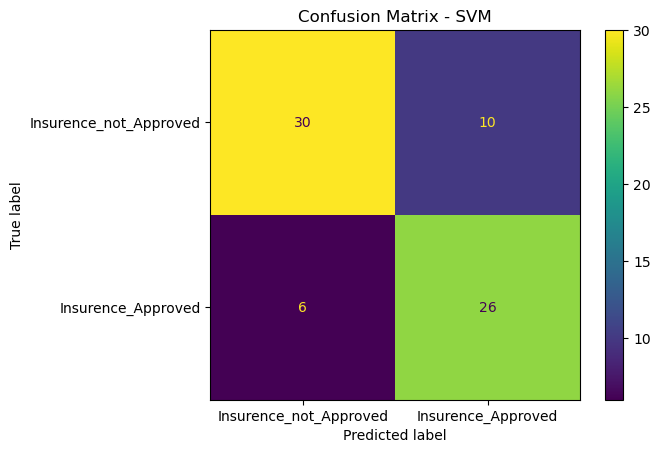

In [33]:
display_cm_svm = ConfusionMatrixDisplay(  # Create a display object for the SVM confusion matrix
    confusion_matrix=cm_svm,  # Use the SVM confusion matrix
    display_labels=["Insurence_not_Approved", "Insurence_Approved"]  # Add readable class labels
)  # End of ConfusionMatrixDisplay

display_cm_svm.plot()  # Ploingt the SVM confusion matrix

plt.title("Confusion Matrix - SVM") 

plt.show()

In [34]:
print("Classification Report - SVM:")  # Print a title for the SVM classification report

print(classification_report(y_test, y_pred_svm, target_names=["Insurence_not_Approved", "Insurence_Approved"])) 

Classification Report - SVM:
                        precision    recall  f1-score   support

Insurence_not_Approved       0.83      0.75      0.79        40
    Insurence_Approved       0.72      0.81      0.76        32

              accuracy                           0.78        72
             macro avg       0.78      0.78      0.78        72
          weighted avg       0.78      0.78      0.78        72



In [35]:
from sklearn.metrics import accuracy_score  # Import accuracy metric

from sklearn.metrics import precision_score  # Import precision metric

from sklearn.metrics import recall_score  # Import recall metric

from sklearn.metrics import f1_score  # Import F1-score metric

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)  # Calculate accuracy for Logistic Regression

precision_logistic = precision_score(y_test, y_pred_logistic)  # Calculate precision for Logistic Regression

recall_logistic = recall_score(y_test, y_pred_logistic)  # Calculate recall for Logistic Regression

f1_logistic = f1_score(y_test, y_pred_logistic)  # Calculate F1-score for Logistic Regression

accuracy_svm = accuracy_score(y_test, y_pred_svm)  # Calculate accuracy for SVM

precision_svm = precision_score(y_test, y_pred_svm)  # Calculate precision for SVM

recall_svm = recall_score(y_test, y_pred_svm)  # Calculate recall for SVM

f1_svm = f1_score(y_test, y_pred_svm)  # Calculate F1-score for SVM

print("All evaluation metrics were calculated successfully.")

All evaluation metrics were calculated successfully.


In [36]:
model_comparison_df = pd.DataFrame({  # Create a DataFrame to compare both models
    "Model": ["Logistic Regression", "SVM"],  # Add model names
    "Accuracy": [accuracy_logistic, accuracy_svm],  # Add accuracy scores
    "Precision": [precision_logistic, precision_svm],  # Add precision scores
    "Recall": [recall_logistic, recall_svm],  # Add recall scores
    "F1-score": [f1_logistic, f1_svm]  # Add F1-scores
})  

display(model_comparison_df)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.791667,0.742857,0.8125,0.776119
1,SVM,0.777778,0.722222,0.8125,0.764706


# <b> Step 11: Ploting the model camparions for both logistic Regression and SVM

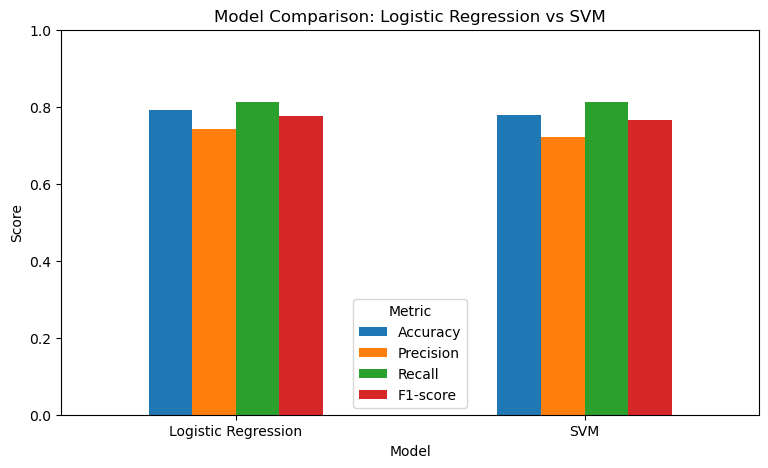

In [37]:
model_comparison_df.set_index("Model").plot(kind="bar", figsize=(9, 5))  # Create a bar chart to compare model metrics

plt.title("Model Comparison: Logistic Regression vs SVM")  # Add chart title

plt.xlabel("Model")  # Add x-axis label

plt.ylabel("Score")  # Add y-axis label

plt.ylim(0, 1)  # Set y-axis range from 0 to 1

plt.xticks(rotation=0)  # Keep model names horizontal

plt.legend(title="Metric")  # Add legend title

plt.show() 

# <b> Which model performed better?

Based on this above chart, the logistic Regression is slightly better than SVM on this dataset.

In this Accuracy, Precision, F1-score is slightly higher than SVM 

And Recall is same in both Logistic regression and SVM.
    

# <b> Which metric is most important for your business problem?

For this dataset, both the Logistic Regression and SVM are the better options for business problem, but based on the camparasion the logistic Regression is the best.

# <b> What do false positives and false negatives mean in your dataset?

In relation to the insurance approval data set, false positives and false negatives are the inaccurate predictions made by the machine learning algorithms, including SVM and Logistic Regression. False positives refer to instances where the algorithm predicts that the application will be approved despite the fact that it was not approved. The number of false positives identified in the SVM algorithm was 10, while for the Logistic Regression algorithm was nine. This implies that some of the applications that should not have been approved were predicted to be approved by both models, which could create additional risks for the insurer. False negatives, on the other hand, are the number of applications that were predicted not to be approved by the algorithm even though they were approved. In both algorithms, the false negatives recorded was six. Thus, it can be concluded that false positives are cases of wrong approvals, whereas false negatives are wrong rejections.

# <b> What is one possible limitation or bias in your model?


The model is depend on the quality of the dataset, but in case the data is incomplete or outdated the model can produce unpredictable outcome or predictions.Based on this it can make poor decision making.

# <b> Why should human judgment still be used?

The Human judgement still required in this models because to finout the dataset is complete without any incomplete data. we need to update the data frequently so that it cannot produce unrealible predictions or outdated. In this dataset the customer data is very important and maintain customer privacy regarding the Age, claim amount, no of previous claims, Documentation complete and policy premium.